# Кластеризация
### Задача
Кластеризация покупателей для выявления покупателей со схожими характеристиками

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import seaborn as sns

Загружаем таблицы

In [55]:
orders = pd.read_csv("../dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("../dataset/olist_order_items_dataset.csv")
customers = pd.read_csv("../dataset/olist_customers_dataset.csv")
products = pd.read_csv("../dataset/olist_products_dataset.csv")
sellers = pd.read_csv("../dataset/olist_sellers_dataset.csv")
order_reviews = pd.read_csv("../dataset/olist_order_reviews_dataset.csv")
order_payments = pd.read_csv("../dataset/olist_order_payments_dataset.csv")
product_translation = pd.read_csv("../dataset/product_category_name_translation.csv")

Перевод названий продуктов на английский

In [56]:
products = products.merge(product_translation, on='product_category_name', how='left')

Объединяем таблицы

In [57]:
order_items_full = order_items.merge(products, on='product_id', how='left')
order_items_full = order_items_full.merge(sellers, on='seller_id', how='left')

In [58]:
orders_full = orders.merge(order_items_full, on='order_id', how='left')
orders_full = orders_full.merge(customers, on='customer_id', how='left')
orders_full = orders_full.merge(order_reviews[['order_id','review_score']], on='order_id', how='left')
df = orders_full

In [59]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,13.0,housewares,9350.0,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,19.0,perfumery,31570.0,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,21.0,auto,14840.0,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,20.0,pet_shop,31842.0,belo horizonte,MG,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,15.0,stationery,8752.0,mogi das cruzes,SP,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0


Агрегируем данные

In [60]:
df["delivery_time"] = (pd.to_datetime(df["order_delivered_customer_date"]) -
                       pd.to_datetime(df["order_purchase_timestamp"])).dt.days

customer_agg = df.groupby("customer_unique_id").agg({
    "price": "mean",
    "freight_value": "mean",
    "delivery_time": "mean",
    "order_id": "nunique",
    "review_score": "mean"
}).reset_index()

customer_agg.columns = ["customer_id", "avg_price", "avg_freight",
                        "avg_delivery_time", "num_orders", "avg_review"]

customer_agg.head()


,customer_id,avg_price,avg_freight,avg_delivery_time,num_orders,avg_review
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,6.0,1,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,3.0,1,4.0
2,0000f46a3911fa3c0805444483337064,69.00,17.22,25.0,1,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,20.0,1,4.0
4,0004aac84e0df4da2b147fca70cf8255,180.00,16.89,13.0,1,5.0


Визуализация данных

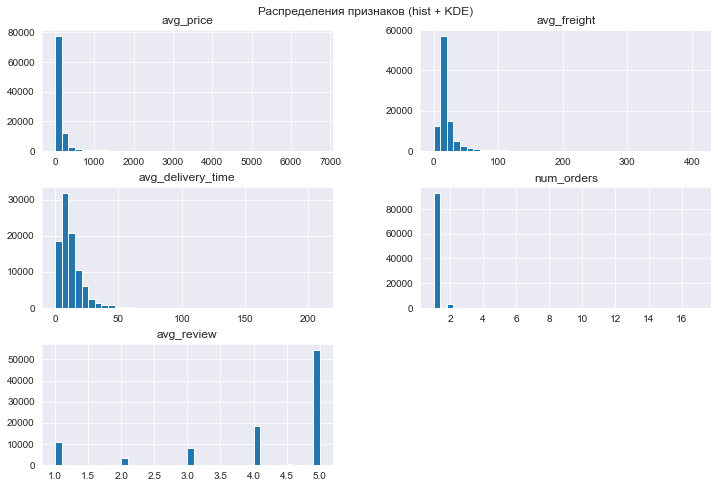

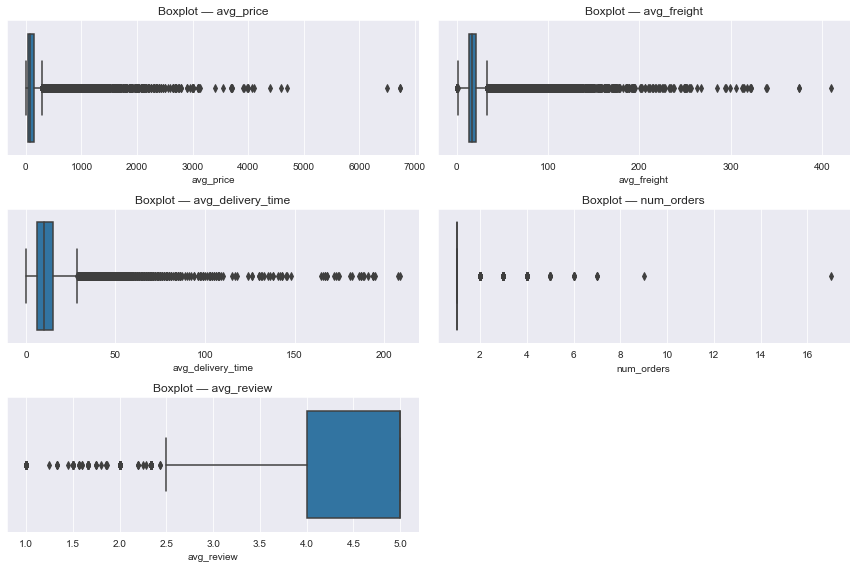

In [61]:
# список признаков, которые будем визуализировать
features = ['avg_price', 'avg_freight', 'avg_delivery_time', 'num_orders', 'avg_review']

# Гистограммы + KDE
customer_agg[features].hist(bins=40, figsize=(12,8), layout=(3,2))
plt.suptitle("Распределения признаков (hist + KDE)", y=0.92)
plt.show()

# Boxplots (для выявления выбросов)
plt.figure(figsize=(12,8))
for i, col in enumerate(features, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x=customer_agg[col])
    plt.title(f"Boxplot — {col}")
plt.tight_layout()
plt.show()

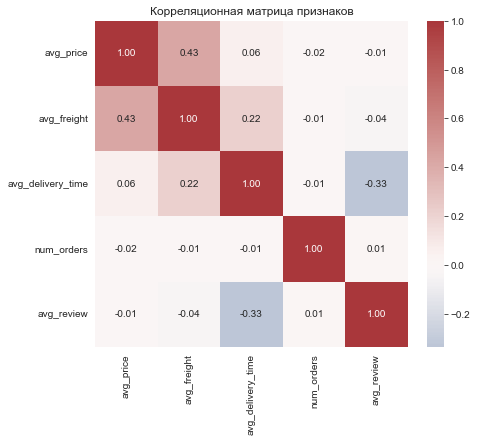

In [62]:
corr = customer_agg[features].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Корреляционная матрица признаков")
plt.show()

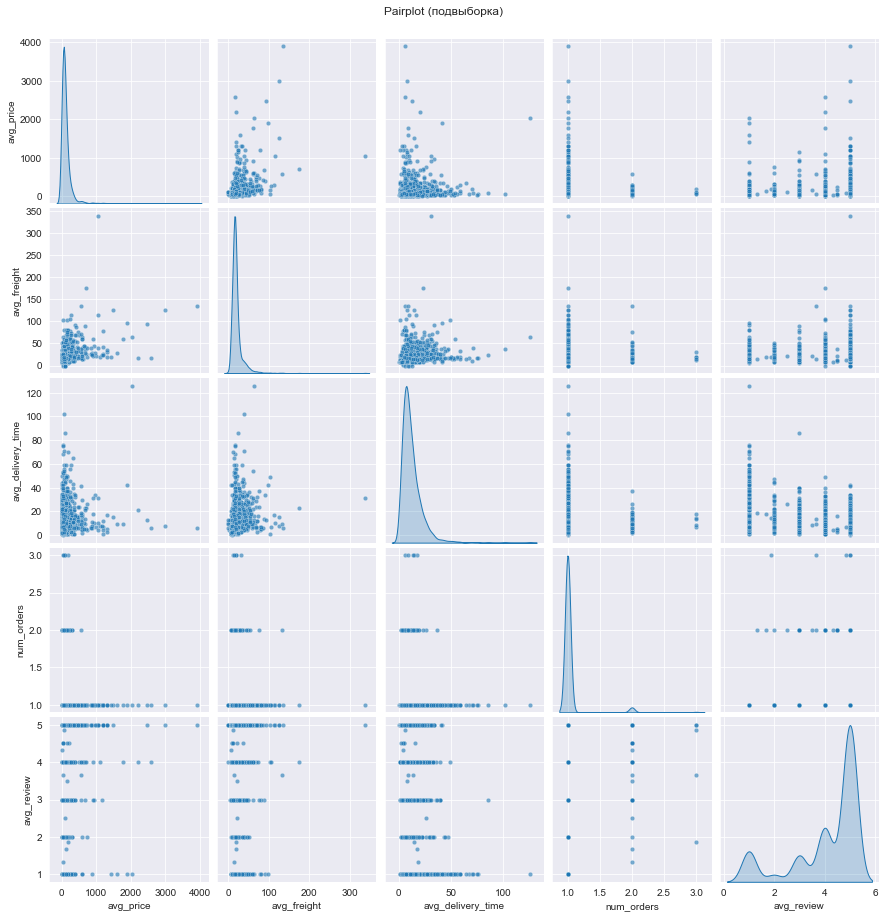

In [63]:
sample = customer_agg.sample(n=min(2000, len(customer_agg)), random_state=42)
sns.pairplot(sample[features], diag_kind='kde', plot_kws={'s':20, 'alpha':0.6})
plt.suptitle("Pairplot (подвыборка)", y=1.02)
plt.show()

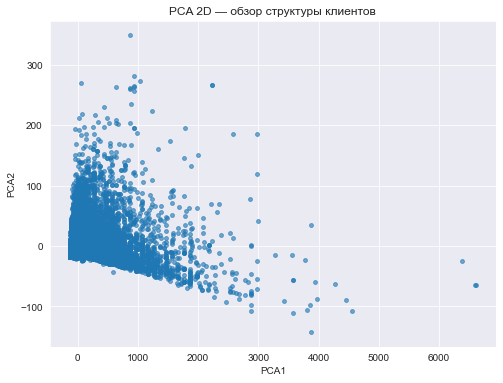

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(customer_agg[features].fillna(0))  # заполняем NaN если есть
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=15, alpha=0.6)
plt.title("PCA 2D — обзор структуры клиентов")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()


Удаляем пропуски и выбросы

In [65]:
customer_agg = customer_agg.dropna()

# Удаление выбросов по IQR
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] > Q1 - 1.5 * IQR) & (df[col] < Q3 + 1.5 * IQR)]
    return df

customer_agg = remove_outliers(customer_agg,
                               ["avg_price", "avg_freight",
                                "avg_delivery_time", "avg_review"])


Масштабирование признаков и создание подвыборки

In [66]:
features = ["avg_price", "avg_freight", "avg_delivery_time",
            "num_orders", "avg_review"]

scaler = StandardScaler()
X = scaler.fit_transform(customer_agg[features])

X_scaled_df = pd.DataFrame(X, columns=features, index=customer_agg.index)

SAMPLE_SIZE = 10000
sample_df = X_scaled_df.sample(SAMPLE_SIZE, random_state=42)

### Кластеризация методом K-средних

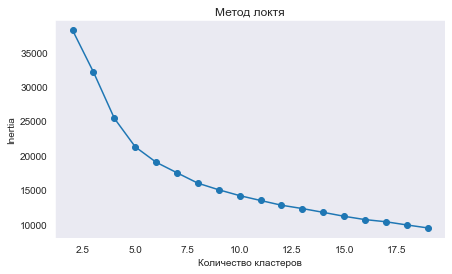

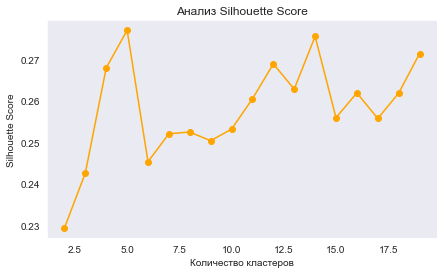

Рекомендуемое количество кластеров по Silhouette Score: 5, максимальный score = 0.277


In [67]:
from sklearn.metrics import silhouette_score

# --- 1. Метод локтя ---
inertia = []

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(sample_df[features].values)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2, 20), inertia, marker="o")
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.grid()
plt.show()


# --- 2. Анализ Silhouette Score ---
sil_scores = []

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(sample_df[features].values)
    score = silhouette_score(sample_df[features].values, labels)
    sil_scores.append(score)

plt.figure(figsize=(7,4))
plt.plot(range(2, 20), sil_scores, marker="o", color='orange')
plt.title("Анализ Silhouette Score")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

optimal_k = range(2, 20)[np.argmax(sil_scores)]
print(f"Рекомендуемое количество кластеров по Silhouette Score: {optimal_k}, максимальный score = {max(sil_scores):.3f}")


In [68]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
sample_df["cluster_kmeans"] = kmeans.fit_predict(sample_df)

### Кластеризация методом DBSCAN

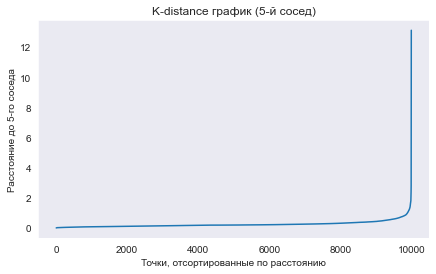

Лучшие параметры DBSCAN: {'eps': 1.8999999999999997, 'min_samples': 3, 'n_clusters': 3}
Silhouette Score: 0.49471652350937456


In [69]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

X = sample_df[features].values

# --- 1. K-distance график для подбора eps ---
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# берём расстояния до 5-й ближайшей точки
k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(7,4))
plt.plot(k_distances)
plt.title("K-distance график (5-й сосед)")
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel("Расстояние до 5-го соседа")
plt.grid()
plt.show()


# --- 2. Подбор eps и min_samples с Silhouette Score ---
eps_values = np.arange(0.5, 2.1, 0.1)
min_samples_values = [3, 5, 7, 10]

best_score = -1
best_params = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue
        score = silhouette_score(X, labels)
        if score > best_score:
            best_score = score
            best_params = {"eps": eps, "min_samples": min_samples, "n_clusters": n_clusters}

print("Лучшие параметры DBSCAN:", best_params)
print("Silhouette Score:", best_score)

# --- 3. Применяем лучшие параметры ---
db = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
sample_df["cluster_dbscan"] = db.fit_predict(X)


### Иерархическая кластеризация (Agglomerative)

In [70]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
sample_df["cluster_agg"] = agg.fit_predict(sample_df)

Оценка моделей

In [71]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

X_features = sample_df[features].values

# --- Silhouette ---
print("Silhouette Score:")
print("KMeans:", silhouette_score(X_features, sample_df["cluster_kmeans"]))
print("DBSCAN:", silhouette_score(X_features, sample_df["cluster_dbscan"]))
print("Agglomerative:", silhouette_score(X_features, sample_df["cluster_agg"]))

# --- Adjusted Rand Index и NMI (сравнение кластеризаций) ---
models = ["cluster_kmeans", "cluster_dbscan", "cluster_agg"]

print("\nAdjusted Rand Index (ARI) между моделями:")
for i in range(len(models)):
    for j in range(i+1, len(models)):
        ari = adjusted_rand_score(sample_df[models[i]], sample_df[models[j]])
        print(f"{models[i]} vs {models[j]}: {ari:.3f}")

print("\nNormalized Mutual Information (NMI) между моделями:")
for i in range(len(models)):
    for j in range(i+1, len(models)):
        nmi = normalized_mutual_info_score(sample_df[models[i]], sample_df[models[j]])
        print(f"{models[i]} vs {models[j]}: {nmi:.3f}")


Silhouette Score:
KMeans: 0.27701233933870856
DBSCAN: 0.49471652350937456
Agglomerative: 0.27701233933870856

Adjusted Rand Index (ARI) между моделями:
cluster_kmeans vs cluster_dbscan: 0.046
cluster_kmeans vs cluster_agg: 1.000
cluster_dbscan vs cluster_agg: 0.046

Normalized Mutual Information (NMI) между моделями:
cluster_kmeans vs cluster_dbscan: 0.182
cluster_kmeans vs cluster_agg: 1.000
cluster_dbscan vs cluster_agg: 0.182


Визуализация результатов

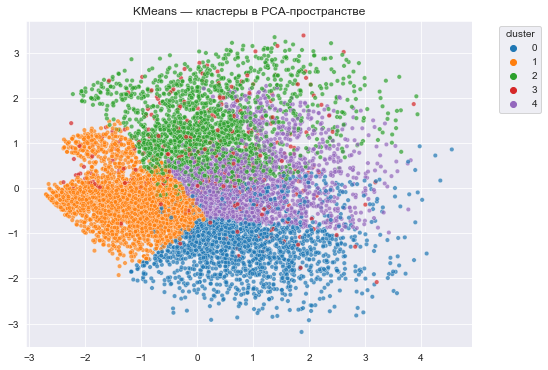

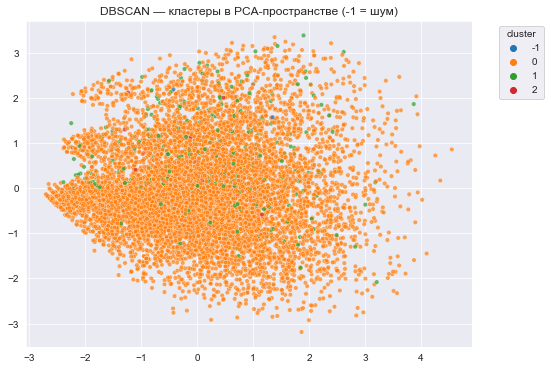

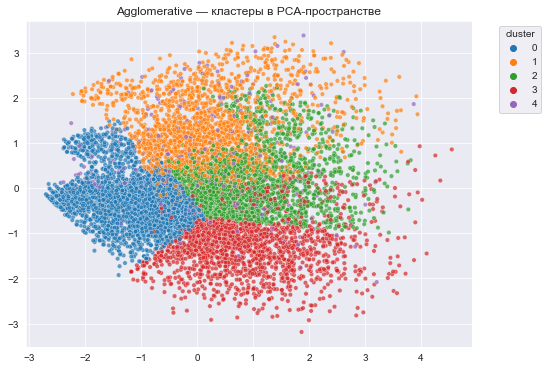

In [72]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(sample_df[features].fillna(0))

# KMeans
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=sample_df['cluster_kmeans'],
                palette='tab10', s=20, alpha=0.7)
plt.title("KMeans — кластеры в PCA-пространстве")
plt.legend(title='cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

# DBSCAN
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=sample_df['cluster_dbscan'],
                palette='tab10', s=20, alpha=0.7)
plt.title("DBSCAN — кластеры в PCA-пространстве (-1 = шум)")
plt.legend(title='cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

# Agglomerative
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=sample_df['cluster_agg'],
                palette='tab10', s=20, alpha=0.7)
plt.title("Agglomerative — кластеры в PCA-пространстве")
plt.legend(title='cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

KMeans silhouette: 0.27701233933870856


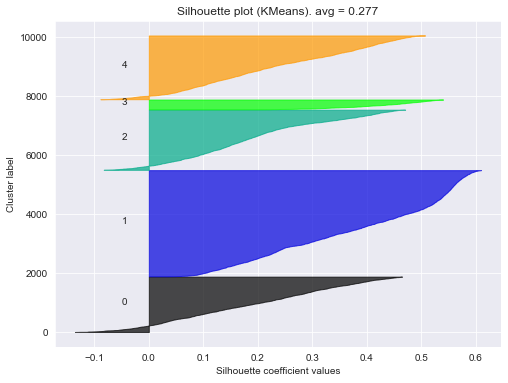

DBSCAN silhouette: 0.49471652350937456


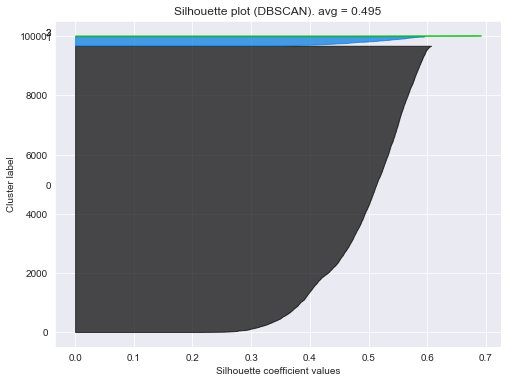

Agglomerative silhouette: 0.27701233933870856


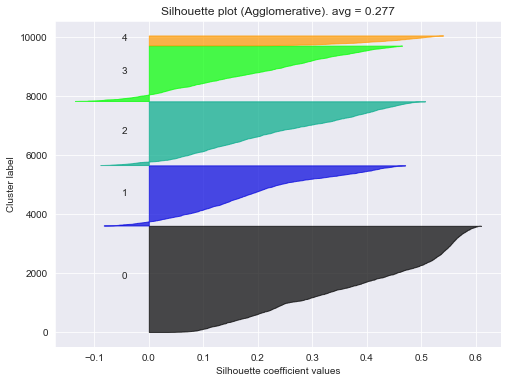

In [73]:
from sklearn.metrics import silhouette_score, silhouette_samples
import seaborn as sns
from matplotlib import cm

# Silhouette plot
def plot_silhouette(X, labels, model_name):
    sil_score = silhouette_score(X, labels)
    print(f"{model_name} silhouette:", sil_score)

    sample_silhouette_values = silhouette_samples(X, labels)
    y_lower = 10
    plt.figure(figsize=(8,6))
    for i in range(len(np.unique(labels))):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / len(np.unique(labels)))
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.title(f"Silhouette plot ({model_name}). avg = {sil_score:.3f}")
    plt.show()

# Вызов для всех моделей
plot_silhouette(X_features, sample_df['cluster_kmeans'].values, "KMeans")
plot_silhouette(X_features, sample_df['cluster_dbscan'].values, "DBSCAN")
plot_silhouette(X_features, sample_df['cluster_agg'].values, "Agglomerative")

Дендограмма для иерархическая кластеризации

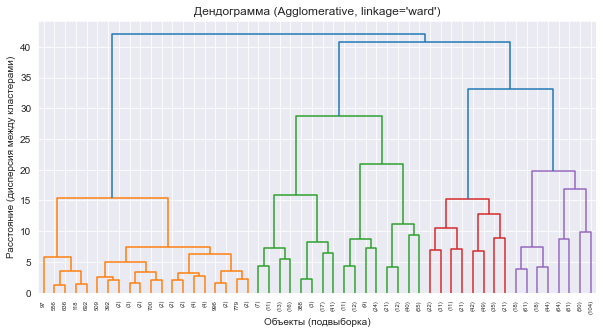

In [74]:
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

sample_idx = sample_df.sample(
    n=min(1000, len(sample_df)),
    random_state=42
).index

X_sample = sample_df.loc[sample_idx, features].values

plt.figure(figsize=(10, 5))
Z = sch.linkage(X_sample, method='ward')
sch.dendrogram(Z, truncate_mode='level', p=5)

plt.title("Дендограмма (Agglomerative, linkage='ward')")
plt.xlabel("Объекты (подвыборка)")
plt.ylabel("Расстояние (дисперсия между кластерами)")
plt.show()


In [75]:
def cluster_profiles_original(df, cluster_col, features, model_name, scaler):
    # --- Средние значения по кластерам в нормализованном масштабе ---
    profile_scaled = df.groupby(cluster_col)[features].mean().round(3)

    # --- Обратная нормализация (возвращаем к исходным единицам) ---
    profile_original = pd.DataFrame(
        scaler.inverse_transform(profile_scaled),
        columns=features,
        index=profile_scaled.index
    )

    print(f"\n=== Профиль кластеров ({model_name}) — исходные значения ===")
    display(profile_original)

    # --- Строим график по исходным значениям ---
    profile_original.plot(kind='bar', figsize=(12,6))
    plt.title(f"Средние признаки по кластерам ({model_name}) — исходные величины")
    plt.xlabel("Кластер")
    plt.ylabel("Значение признака")
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.show()

    return profile_original



=== Профиль кластеров (KMeans) — исходные значения ===


,avg_price,avg_freight,avg_delivery_time,num_orders,avg_review
cluster_kmeans,,,,,
0,168.733844,18.768542,8.876513,0.999920,4.807211
1,53.959970,12.172545,5.948131,0.999920,4.902223
2,69.286028,15.829830,10.424295,0.999920,3.587027
3,82.038681,15.616736,10.278685,2.083824,4.493543
4,67.170117,18.600049,16.016803,0.999920,4.852765


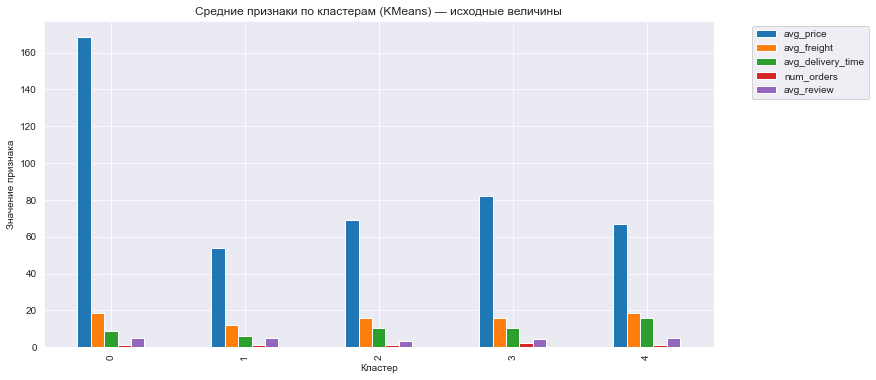


=== Профиль кластеров (DBSCAN) — исходные значения ===


,avg_price,avg_freight,avg_delivery_time,num_orders,avg_review
cluster_dbscan,,,,,
-1,84.268965,16.464156,11.756358,4.000019,4.569031
0,82.438988,15.661337,9.707030,0.999920,4.595713
1,82.839296,15.696027,10.305649,1.999953,4.478575
2,65.626074,13.802960,9.200091,2.999986,4.753198


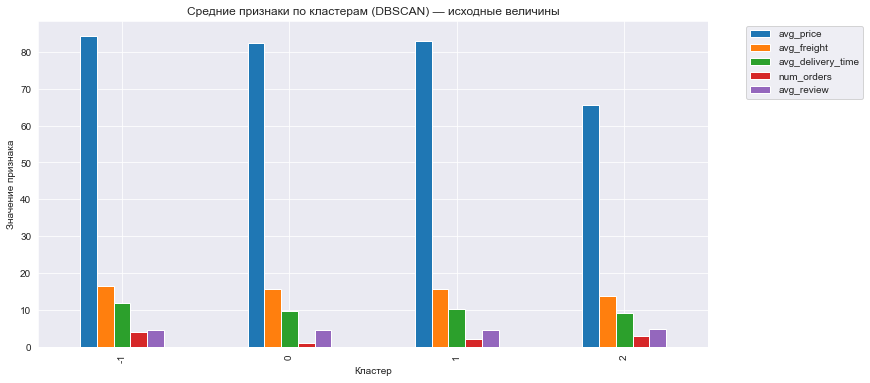


=== Профиль кластеров (Agglomerative) — исходные значения ===


,avg_price,avg_freight,avg_delivery_time,num_orders,avg_review
cluster_agg,,,,,
0,53.959970,12.172545,5.948131,0.999920,4.902223
1,69.286028,15.829830,10.424295,0.999920,3.587027
2,67.170117,18.600049,16.016803,0.999920,4.852765
3,168.733844,18.768542,8.876513,0.999920,4.807211
4,82.038681,15.616736,10.278685,2.083824,4.493543


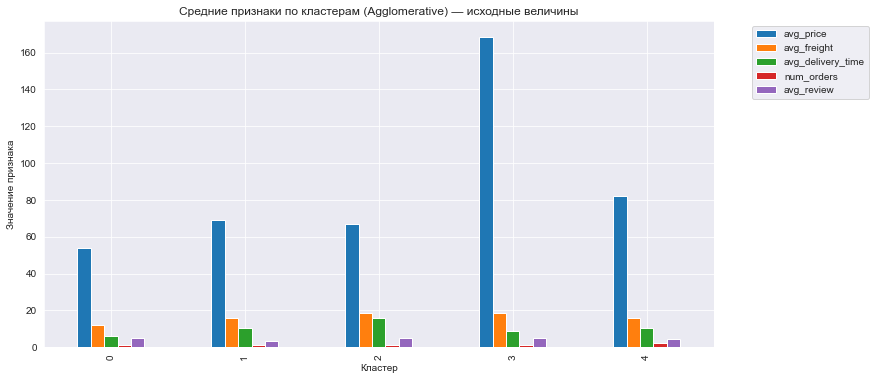

In [76]:
profile_kmeans_original = cluster_profiles_original(
    sample_df, 'cluster_kmeans', features, "KMeans", scaler
)

profile_dbscan_original = cluster_profiles_original(
    sample_df, 'cluster_dbscan', features, "DBSCAN", scaler
)

profile_agg_original = cluster_profiles_original(
    sample_df, 'cluster_agg', features, "Agglomerative", scaler
)